<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/todas_etapas_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Perceptron CV Accuracy: 0.9604 (+/- 0.0329)
MLPClassifier CV Accuracy: 0.9758 (+/- 0.0352)
RandomForest CV Accuracy: 0.9582 (+/- 0.0352)
SVM CV Accuracy: 0.9736 (+/- 0.0329)
Best MLP params: {'hidden_layer_sizes': (50,), 'learning_rate': 'constant'}
Best MLP CV Accuracy: 0.9780


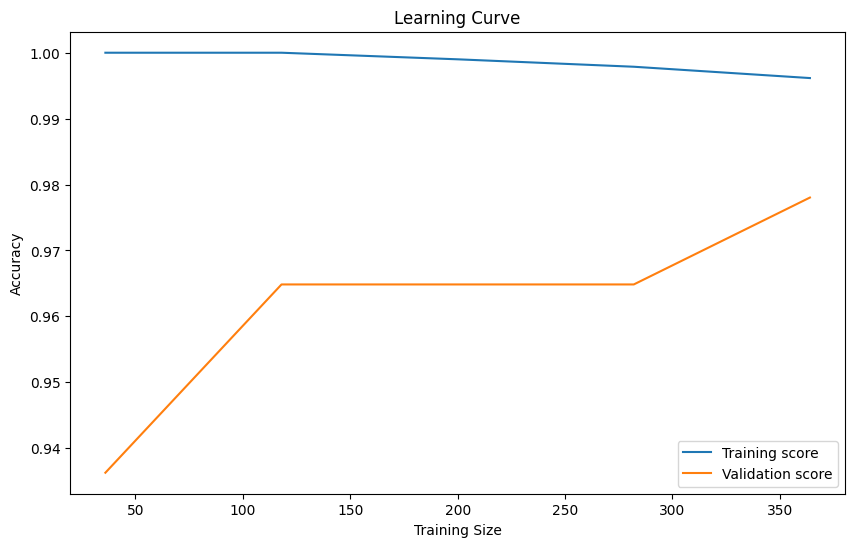

Best model: Perceptron with accuracy 0.9737
Confusion Matrix:
[[42  1]
 [ 2 69]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



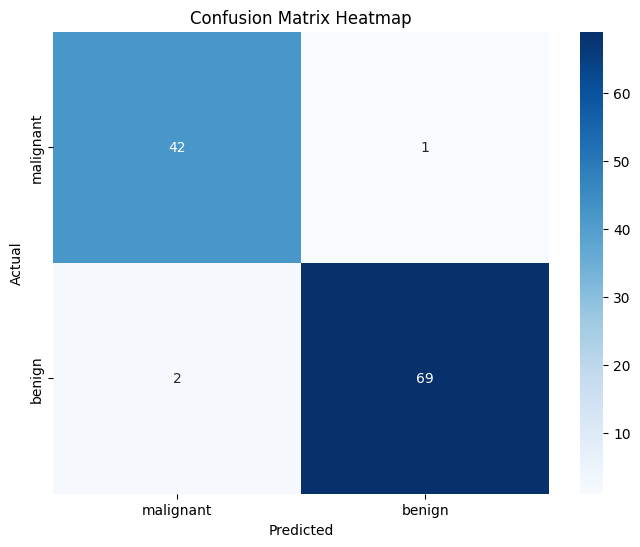

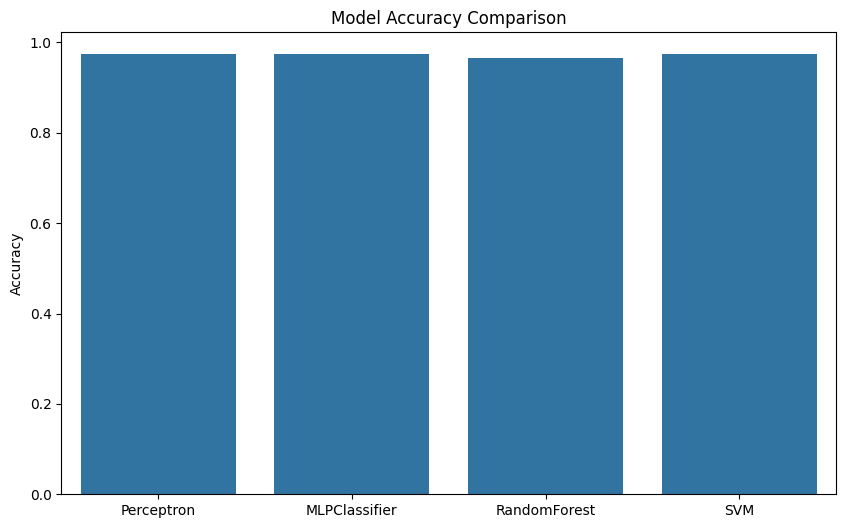

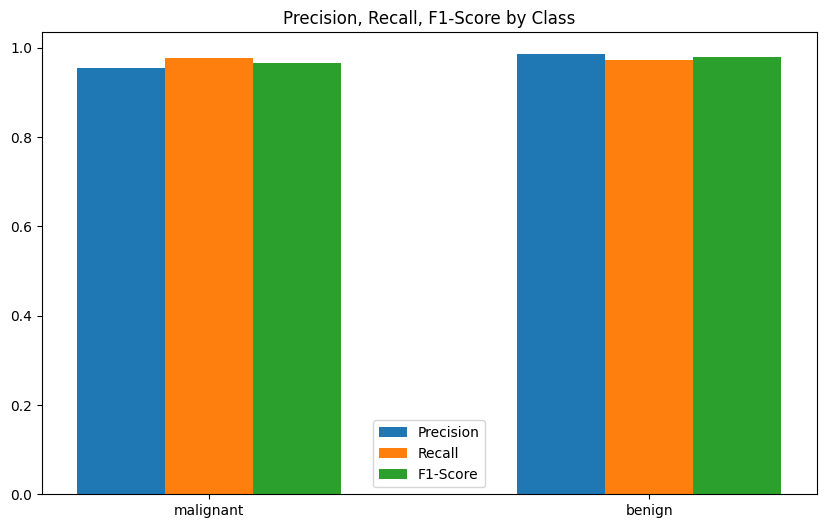

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support

# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Preprocessing: Remove unnecessary columns (none in this dataset), normalize with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test 80/20 with random_state=42
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models with random_state=42
models = {
    'Perceptron': Perceptron(random_state=42),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# K-Fold cross-validation (k=5) for each model
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f'{name} CV Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})')

# GridSearchCV for MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'learning_rate': ['constant', 'adaptive']
}
grid_search = GridSearchCV(MLPClassifier(random_state=42, max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_mlp = grid_search.best_estimator_
print(f'Best MLP params: {grid_search.best_params_}')
print(f'Best MLP CV Accuracy: {grid_search.best_score_:.4f}')

# Update models with best MLP
models['MLPClassifier'] = best_mlp

# Learning curve for the best model (assuming MLP as example, but can be adjusted)
train_sizes, train_scores, val_scores = learning_curve(best_mlp, X_train, y_train, cv=5, random_state=42)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, val_mean, label='Validation score')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Compare accuracies
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, y_pred)

# Best model based on test accuracy
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]
print(f'Best model: {best_model_name} with accuracy {accuracies[best_model_name]:.4f}')

# Confusion matrix and classification report for best model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(classification_report(y_test, y_pred_best))

# Plots
# 1. Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Bar chart comparing models
model_names = list(accuracies.keys())
acc_values = list(accuracies.values())
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=acc_values)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

# 3. Precision, Recall, F1 by class for best model
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_best, average=None)
classes = data.target_names
plt.figure(figsize=(10, 6))
x = np.arange(len(classes))
width = 0.2
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')
plt.xticks(x, classes)
plt.title('Precision, Recall, F1-Score by Class')
plt.legend()
plt.show()